In [ ]:
pip install qiskit qiskit-aer pylatexenc

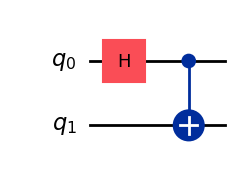

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)

qc.cx(0, 1)

qc.draw('mpl')

The `data` attribute provides direct access to the list of instructions that make up the circuit. Each item in the list is a `CircuitInstruction` object containing the operation and the qubits/clbits it applies to.

In [ ]:
qc.data

[CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())]

The `global_phase` attribute tracks the global phase of the circuit in radians. While global phase does not affect measurement probabilities, it is crucial when controlling the circuit or combining it with others.

In [ ]:
qc.global_phase

0.0

You can access the quantum (`qregs`) and classical (`cregs`) registers associated with the circuit. This is useful for inspecting the circuit's structure.

In [ ]:
qc.qregs

[QuantumRegister(2, 'q')]

In [ ]:
qc.cregs

[]

#Layout
The layout attribute (typically populated after transpilation) shows how the virtual qubits in your circuit map to the physical qubits on a device.

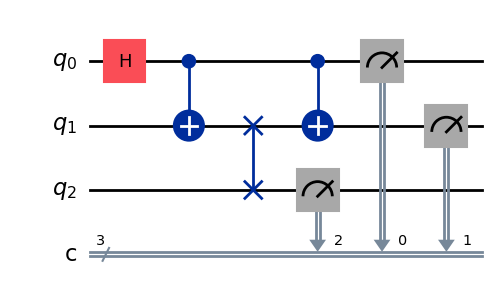

In [ ]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager

qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.swap(1, 2)
qc.cx(0, 1)

qc.measure([0, 1, 2], [0, 1, 2])
qc.draw('mpl')

In [ ]:
backend = GenericBackendV2(3)

pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
transpiled = pass_manager.run(qc)

transpiled.layout

TranspileLayout(initial_layout=Layout({
0: <Qubit register=(3, "q"), index=0>,
1: <Qubit register=(3, "q"), index=1>,
2: <Qubit register=(3, "q"), index=2>
}), input_qubit_mapping={<Qubit register=(3, "q"), index=0>: 0, <Qubit register=(3, "q"), index=1>: 1, <Qubit register=(3, "q"), index=2>: 2}, final_layout=None, _input_qubit_count=3, _output_qubit_list=[<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>])

In [ ]:
transpiled.layout.routing_permutation()

[0, 1, 2]

#**Circuit Construction Method**

helps in manipulating and creqating circuit objects

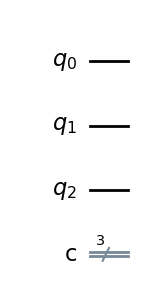

In [ ]:
qc2 = qc.copy_empty_like()
qc2.draw('mpl')

### Copy

Create a deep copy of the circuit. This is useful when you want to create a new circuit based on an existing one without modifying the original.

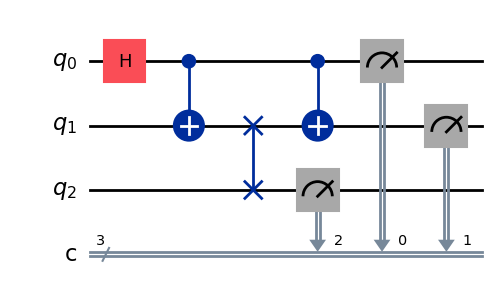

In [ ]:
qccopy = qc.copy()
qccopy.draw('mpl')

##**from_qasm_str**

Imports a circuit that is defined in OpenQASM 2.0 string format.

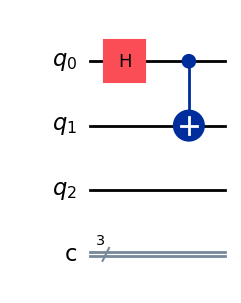

In [ ]:
qasm_string = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
cx q[0],q[1];"""

qc = QuantumCircuit.from_qasm_str(qasm_str=qasm_string)
qc.draw('mpl')

##**Data Objects**

Methods for managing the wires (qubits and classical bits) and variables in the circuit.

In [ ]:
qc = QuantumCircuit(2)
my_var = qc.add_var("my_var", False)


## **add_bits**

Manually add individual quantum or classical bits to the circuit. This is useful for building flexible circuits wire-by-wire.

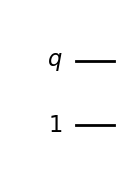

In [ ]:
from qiskit.circuit import Qubit, Clbit
from qiskit import QuantumCircuit
qc = QuantumCircuit(1)
new_bit = Qubit()
qc.add_bits([new_bit])
qc.draw('mpl')

##**add_register**

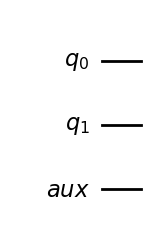

In [ ]:
from qiskit import QuantumRegister

qc = QuantumCircuit(2)
qr = QuantumRegister(1, 'aux')
qc.add_register(qr)
qc.draw('mpl')

## **add_input**

Add a real-time classical input variable. This is a feature for dynamic circuits where inputs might be provided at runtime.

In [ ]:
from qiskit.circuit.classical import types

qc = QuantumCircuit(1)

# Preferred usage: pass an instance from qiskit.circuit.classical.types
# Older code sometimes used a deprecated `dtype` keyword or different signatures,
# so we attempt the modern call and provide a fallback with an explanatory note.

try:
  # Add a Boolean input variable named 'x' (modern API)
  x_var = qc.add_input('x', types.Bool())
  print("Successfully added the variable: ", x_var)
except TypeError:
  try:
    # Some qiskit version accept the type class itself as a fallback
    x_var = qc.add_input("x", types.Bool)
    print('success')
  except Exception as e:
    print('Error', e)

# Note: if you previously saw errors, that was likely due to a deprecated/changed
# add_input signature in older Qiskit versions. The approach above attempts
# the modern call first and falls back if needed.

Successfully added the variable:  Var(UUID('cb7c5b6d-c719-4583-b7e9-f0b7179d257a'), Bool(), name='x')


# **Working with Bits**

Qiskit provides tools to seamlessly convert between integer indices and bit instances.

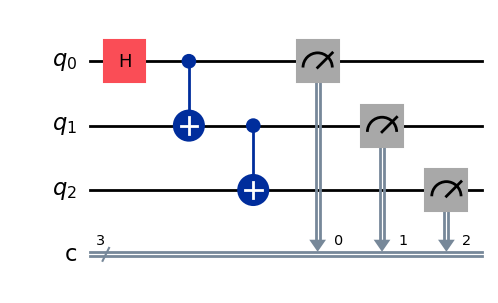

In [ ]:
qc =  QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw('mpl')

In [ ]:
qc.qubits

[<Qubit register=(3, "q"), index=0>,
 <Qubit register=(3, "q"), index=1>,
 <Qubit register=(3, "q"), index=2>]

In [ ]:
qc.data[0].qubits[0]

<Qubit register=(3, "q"), index=0>

In [ ]:
# the qubits and clbits are not integers
# assert isinstance(qc.data[0].qubits[0], Qubit) #isinstance(object, type)
# but we can use find_bit to retreive them.
# assert qc.find_bit(qc.data[0].qubits[0]).index == 0

simple = [
    (
        instruction.operation.name,
        [qc.find_bit(bit).index for bit in instruction.qubits],
        [qc.find_bit(bit).index for bit in instruction.qubits]
    )
    for instruction in qc.data
]

simple

[('h', [0], [0]),
 ('cx', [0, 1], [0, 1]),
 ('cx', [1, 2], [1, 2]),
 ('measure', [0], [0]),
 ('measure', [1], [1]),
 ('measure', [2], [2])]

# **Adding Operations**

Methods to add instructions and combine circuits.
This includes operations that change the circuit structure; for example, `tensor` composes systems into a larger Hilbert space — i.e., it is equivalent to creating a larger system whose state space is the tensor product of the operand systems.

In [ ]:
qc2 = QuantumCircuit(2)
qc2.x(0)
qc.x(0)
qc.tensor(qc2).draw()

┌───┐                                 
q_0: ┤ X ├─────────────────────────────────
     └───┘                                 
q_1: ──────────────────────────────────────
     ┌───┐          ┌─┐┌───┐┌───┐┌───┐┌───┐
q_2: ┤ H ├──■───────┤M├┤ X ├┤ X ├┤ X ├┤ X ├
     └───┘┌─┴─┐     └╥┘└┬─┬┘└───┘└───┘└───┘
q_3: ─────┤ X ├──■───╫──┤M├────────────────
          └───┘┌─┴─┐ ║  └╥┘  ┌─┐           
q_4: ──────────┤ X ├─╫───╫───┤M├───────────
               └───┘ ║   ║   └╥┘           
c: 3/════════════════╩═══╩════╩════════════
                     0   1    2

##**append**
The foundational method to add any `Instruction` object to the circuit. Most gate methods call this internally.

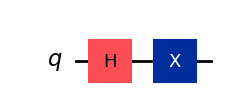

In [ ]:
from qiskit.circuit.library import XGate

qc = QuantumCircuit(1)
qc.h(0)
qc.append(XGate(), [0])
qc.draw('mpl')

##**compose**

Combine this circuit with another circuit. Unlike `append`, `compose` flattens the other circuit into this one, rather than adding it as a single opaque instruction.

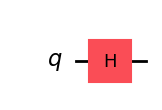

In [ ]:
qc1 = QuantumCircuit(1)
qc1.h(0)

qc2 = QuantumCircuit(1)
qc2.x(0)


qc = qc1.compose(qc2, [0])

qc1.draw('mpl')

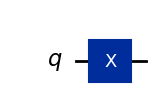

In [ ]:
qc2.draw('mpl')

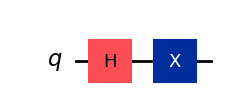

In [ ]:
qc.draw('mpl')

## **Compose** v/s **Append**

`compose()` flattens the second circuit into the first so its gates appear inline. `append()` adds the other circuit as a single opaque instruction (a boxed gate) — visually you'll see one case expanded and the other as a single box. The example below shows `append()` on the same small circuits so you can compare the two drawings.

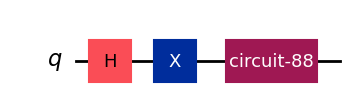

In [ ]:
qc_cp = qc.copy()
qc_cp.append(qc2, [0])
qc_cp.draw('mpl')

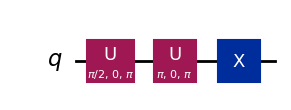

In [ ]:
qc_cp.decompose().draw('mpl')

In [ ]:
for inst in qc_cp.data:
    print(inst.operation.name)

h
x
circuit-88


In [ ]:
for inst in qc_cp.decompose().data:
    print(inst.operation.name)

u
u
x


So the gates were not reordered. The two u gates correspond to the two H gates (one in the main circuit and one inside circuit-88), and the X gate remained X. The visual appearance changed because the boxed circuit was expanded and the H gates were rewritten in terms of the lower-level U gate.

## **delay**

Apply a delay (idle time) to a qubit. This is used in scheduling and noise characterization tasks. Delays represent idle/waiting time for qubits — they model scheduling pauses and exposure to decoherence, so they are useful when reasoning about timing and noise in experiments.

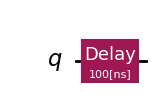

In [ ]:
qc = QuantumCircuit(1)
qc.delay(100, 0, unit='ns')
qc.draw('mpl')

#**Initialize**

initialize qubit to a specific state.

*Note :this is not a unitary operation in general and involves reset/prep*

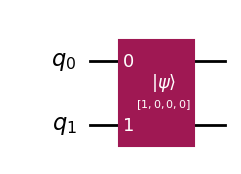

In [ ]:
qc = QuantumCircuit(2)

qc.initialize([1, 0, 0, 0], [0, 1])
qc.draw('mpl')

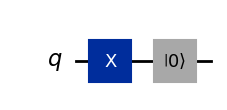

In [ ]:
qc = QuantumCircuit(1)
qc.x(0)
qc.reset(0)
qc.draw('mpl')


# Reset a qubit to the |0> state mid-circuit. This is a non-unitary dynamic operation.